# Efficiency comparison of s-stage IRKGL schemes (Schwarzschild-black-hole)

Running the code cells below will compute and automatically generate the following figures:

-  **From Section 5.2**:

    - **Figure 1(a)**, saved as **`Fig1.pdf`**
    - **Figure 1(b)**, saved as **`Fig2.pdf`**
  

<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Initial-value-problem:-Schwarzschild-black-hole">Initial-value-problem:-Schwarzschild-black-hole</a></li> 
    <li><a href="#IRKGL16-integrations">IRKGL16 integrations</a></li>
    <li><a href="#Figures">Figures</a></li>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
using BenchmarkTools
using IRKGaussLegendre


Base.@boundscheck false
pkgversion(IRKGaussLegendre) # must be v"0.2.13" or greater

v"0.2.13"

### Utils

In [2]:
mutable struct tsolutions_IRKGL16
    dts
    sols
    retcodes
    iters
    cpus
    fcns
    MaxΔHglobal
    MaxΔHlocal
    wcpu
    cpu_idx
end

function run_many_IRKGL16(alg, prob, ddt0, HAM; wcpu=true)

    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    iters=zero(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]
    
    sols=Array{IRKGaussLegendre.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B,parms_B)
    
    for i in 1:length(ddt0)
        
        print(",",ddt0[i])    
        dt0=ddt0[i]
        
        sols[i]=solve(prob,alg,dt=dt0, adaptive=false)
        if sols[i].retcode==ReturnCode.Success
           iters[i]=sols[i].stats.nfpiter
           fcns[i]=iters[i]*8
        else
           retcodes[i]=false
           iters[i]=Inf
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solve(prob,alg, dt=dt0, adaptive=false, save_everystep = false)
            cpus[i]= @belapsed solve($prob,$alg, dt=$dt0, adaptive=false, save_everystep = false)
        end
        
    end

    println("")
    return tsolutions_IRKGL16(ddt0, sols,retcodes,iters,cpus,fcns,MaxΔHglobal,MaxΔHlocal,wcpu,-1)

end  

run_many_IRKGL16 (generic function with 1 method)

##### <a href="#top">Back to the top</a>

## Initial value problem: Schwarzschild black-hole

In [3]:
""" 
Hamiltonian for Schwarzschild problem
(polar coordinates)  
"""
function Ham_Schwarzschild(u,parms)
     
   E=parms[1]
   L=parms[2]
   β=parms[3]
   r=u[1]
   θ=u[2]
   pr=u[3]
   pθ=u[4]

   E2=E*E
   r2=r*r
   pr2=pr*pr
   pθ2=pθ*pθ
   sinθ=sin(θ)
   sinθ2=sinθ*sinθ
   invsinθ2=1/sinθ2
   invr=1/r
   invr2=invr*invr


   H1=1/2*invr2*invsinθ2*(L-β/2*r2*sinθ2)^2-1/2*(r/(r-2))*E2
   H2= 1/2*(pr2+pθ2*invr2)
   H3= -invr*pr2

   return H1+H2+H3

end

""" 
ODE for Schwarzschild problem
(polar coordinates)  
"""
function SchwarzschildODE!(F,u,parms,t)

   E=parms[1]
   L=parms[2]
   β=parms[3]
   r=u[1]
   θ=u[2]
   pr=u[3]
   pθ=u[4]

   E2=E*E
   L2=L*L
   β2=β*β

   r2=r*r
   pr2=pr*pr
   pθ2=pθ*pθ
   invr=1/r
   invr2=invr*invr
   invr3=invr2*invr
   # sinθ, cosθ = sincos(θ) # no exist at SIMD
   sinθ=sin(θ)
   cosθ=cos(θ)
   sinθ2=sinθ*sinθ
   invsinθ=1/sinθ
   invsinθ2=invsinθ*invsinθ
   invsinθ3=invsinθ2*invsinθ
   sinθcosθ=sinθ*cosθ


   F[1]=(1-2*invr)*pr
   F[2]=pθ*invr2
   F[3]=-1/4*β2*r*sinθ2-(r/(r-2))^2*invr2*E2+L2*invsinθ2*invr3-pr2*invr2+pθ2*invr3
   F[4]=L2*cosθ*invsinθ3*invr2-1/4*β2*r2*sinθcosθ

   return nothing

end


""" 
Initial values for Schwarzschild problem
(polar coordinates)  
"""
function InitialSchwarzschild(T = Float64)
    
    parms = BigFloat[0.995,4.6,8.9e-5]

    r = 11
    θ =  pi/2
    pr = 0
    u0 = BigFloat[r, θ, pr, 0]

    pθ = r * sqrt(-1 -2*Ham_Schwarzschild(u0,parms))

    parms = convert.(T, parms)
 
    u0 = convert.(T, [r, θ, pr, pθ])

    return u0, parms

end



InitialSchwarzschild

In [4]:
u0, parms = InitialSchwarzschild()

t0=0.
tF=1e5  #1e4
tspan=(t0,tF)

prob = ODEProblem{true,SciMLBase.FullSpecialize}(SchwarzschildODE!, u0, tspan , parms)

HAM=Ham_Schwarzschild
@show(HAM(u0,parms));

HAM(u0, parms) = -0.5


<a href="#top">Back to the top</a>

## IRKGL16 integrations


###  IRKGL16 integrations (s=8)

In [5]:
ddt0_irk16=collect(10.:2:30)

println("simd:")
alg=IRKGL16(simd=true, fseq=false)
sols_irk16_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM)
#
println("seq:")
alg=IRKGL16(simd=false, fseq=true)
sols_irk16_seq=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM)
#
println("hybrid:")
alg=IRKGL16(simd=true, fseq=true)
sols_irk16_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM);

simd:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0
seq:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0
hybrid:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


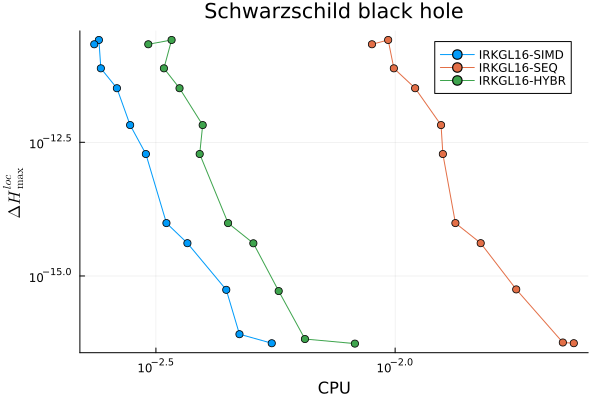

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [6]:
#
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb]
labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

###  IRKGL12 integrations (s=6)

In [7]:
ddt0_irk12=ddt0_irk16*3/4 
steps_irk12=tF./ddt0_irk12

println("simd:")
alg=IRKGL16(s=6,simd=true, fseq=false)
sols_irk12_simd=run_many_IRKGL16(alg, prob, ddt0_irk12, HAM)
#
println("seq:")
alg=IRKGL16(s=6,simd=false, fseq=true)
sols_irk12_seq=run_many_IRKGL16(alg,prob,ddt0_irk12, HAM)
#
println("hybrid:")
alg=IRKGL16(s=6,simd=true, fseq=true)
sols_irk12_hyb=run_many_IRKGL16(alg,prob,ddt0_irk12, HAM);


simd:
,7.5,9.0,10.5,12.0,13.5,15.0,16.5,18.0,19.5,21.0,22.5
seq:
,7.5,9.0,10.5,12.0,13.5,15.0,16.5,18.0,19.5,21.0,22.5
hybrid:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0


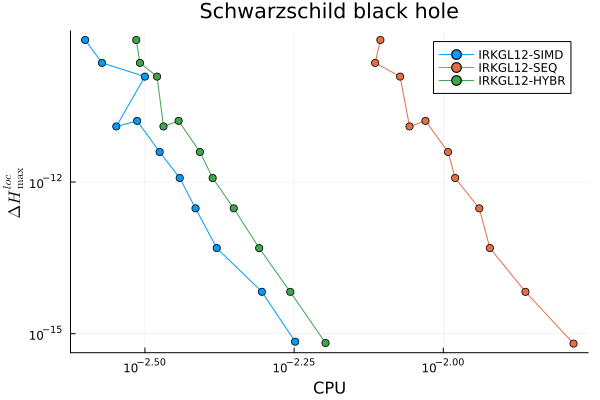

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [21]:
#--
sols2plot=[sols_irk12_simd, sols_irk12_seq, sols_irk12_hyb]
labels2plot=["IRKGL12-SIMD", "IRKGL12-SEQ", "IRKGL12-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL8 integrations (s=4)

In [9]:
ddt0_irk8=ddt0_irk16/2 
steps_irk8=tF./ddt0_irk8

println("simd:")
alg=IRKGL16(s=4,simd=true, fseq=false)
sols_irk8_simd=run_many_IRKGL16(alg, prob, ddt0_irk8, HAM)
#
println("seq:")
alg=IRKGL16(s=4,simd=false, fseq=true)
sols_irk8_seq=run_many_IRKGL16(alg,prob,ddt0_irk8,HAM)
#
println("hybrid:")
alg=IRKGL16(s=4,simd=true, fseq=true)
sols_irk8_hyb=run_many_IRKGL16(alg,prob,ddt0_irk8,HAM);

simd:
,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
seq:
,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
hybrid:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0


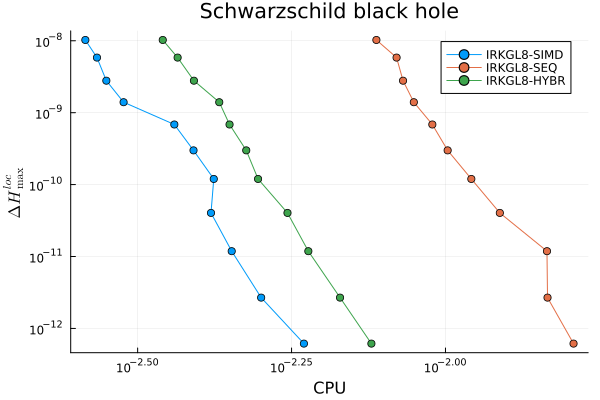

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [22]:
#
sols2plot=[sols_irk8_simd, sols_irk8_seq, sols_irk8_hyb]
labels2plot=["IRKGL8-SIMD", "IRKGL8-SEQ", "IRKGL8-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL4 integrations (s=2)

In [11]:
ddt0_irk4=ddt0_irk16/4 
steps_irk4=tF./ddt0_irk4

println("simd:")
alg=IRKGL16(s=2,simd=true, fseq=false)
sols_irk4_simd=run_many_IRKGL16(alg, prob, ddt0_irk4, HAM)
#
println("seq:")
alg=IRKGL16(s=2,simd=false, fseq=true)
sols_irk4_seq=run_many_IRKGL16(alg,prob,ddt0_irk4,HAM)
#
println("hybrid:")
alg=IRKGL16(s=2,simd=true, fseq=true)
sols_irk4_hyb=run_many_IRKGL16(alg,prob,ddt0_irk4,HAM);

simd:
,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5
seq:
,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5
hybrid:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0


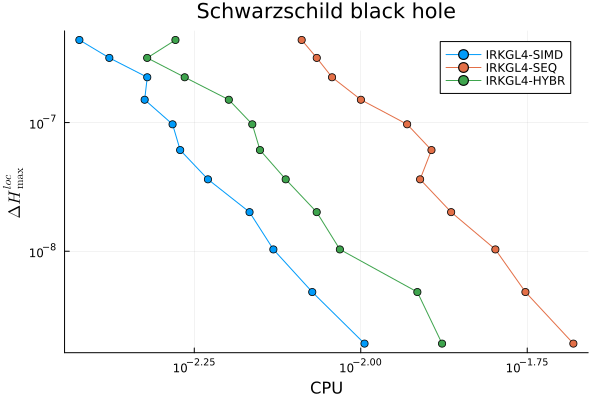

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [24]:
#
sols2plot=[sols_irk4_simd, sols_irk4_seq, sols_irk4_hyb]
labels2plot=["IRKGL4-SIMD", "IRKGL4-SEQ", "IRKGL4-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

## Figures

In [25]:
sols2plot=[sols_irk16_simd, sols_irk16_seq,
           sols_irk12_simd, sols_irk12_seq,
           sols_irk8_simd, sols_irk8_seq,
           sols_irk4_simd, sols_irk4_seq
           ]

labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", 
             "IRKGL12-SIMD", "IRKGL12-SEQ",
             "IRKGL8-SIMD", "IRKGL8-SEQ",
             "IRKGL4-SIMD", "IRKGL4-SEQ"
]

labels2plot_=["IRKGL16", "IRKGL16", 
             "IRKGL12", "IRKGL12",
             "IRKGL8", "IRKGL8",
             "IRKGL4", "IRKGL4"
]

markershape2plot=[:circle, :xcross, :circle, :xcross, 
                  :circle, :xcross, :circle, :xcross]


ls2plot=[:solid, :solid, :solid, :solid, 
         :solid, :solid, :solid, :solid]

colors2plot = [:red, :red, :blue, :blue, 
               :green, :green, :orange, :orange]

stages = [8,8,6,6,4,4,2,2];

### Figure1

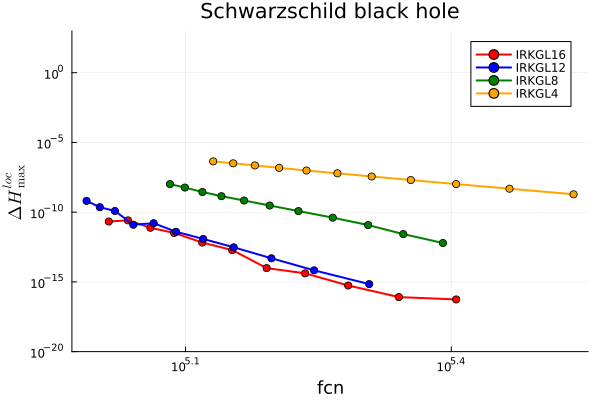

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [26]:
yrange=(1e-20, 1e3)
xrange=(1,50)


pl3=plot(scale=:log10,
         ylimits=yrange,    
         title="Schwarzschild black hole", 
         xlabel="fcn", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
         legend=:topright,
         guidefont=font(12), labelsize=10)

for i in 1:2:length(sols2plot)
       
    sols=sols2plot[i]
    fcn=stages[i]*(sols.iters)
    #fcn=sols.fcns
    plot!(pl3, fcn , sols.MaxΔHlocal,
          markershape=:circle, lw=2,
          label=labels2plot_[i], color=colors2plot[i])
end

display(pl3)

In [27]:
savefig("./figures/Fig1.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-2-Efficiency comparison of s-stage IRKGL schemes/figures/Fig1.pdf"

### Figure2

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


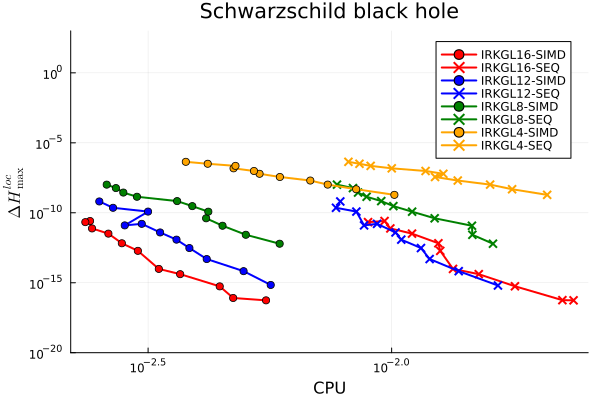

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [28]:
yrange=(1e-20, 1e3)

xrange=(1,50)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=markershape2plot[1], lw=2, ls=ls2plot[1],
          ylimits=yrange, 
          label=labels2plot[1], color=colors2plot[1],
          title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}")

for i in 2:length(sols2plot)
    
    sols=sols2plot[i]

    plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
             markershape=markershape2plot[i], lw=2, ls=ls2plot[i],
             label=labels2plot[i], color=colors2plot[i],
             scale=:log10)

    
end

plot(pl1)


In [29]:
savefig("./figures/Fig2.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-2-Efficiency comparison of s-stage IRKGL schemes/figures/Fig2.pdf"